# 02. Backends, parity, and speed evidence

This notebook shows how pySTAMPS switches kernel modality, how to run a small parity check, and how to time Python versus native kernels. It is intentionally compact: use `make benchmark` for publishable speed claims and `make audit` for release-grade parity claims.


In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pystamps.config import RunConfig
from pystamps.kernels import (
    describe_backend_matrix,
    run_stage2_grid_accumulate_kernel,
    run_stage2_histogram_kernel,
    run_stage2_topofit_coh_row_invariant_kernel,
    run_stage2_topofit_kernel,
    run_stage2_topofit_row_invariant_kernel,
    run_stage4_edge_stats_kernel,
    run_stage7_scla_kernel,
    run_stage8_edge_noise_kernel,
)
from pystamps.verify import verify_run_against_golden

REPO_ROOT = Path.cwd()
DATASET = REPO_ROOT / "inputs_and_outputs" / "InSAR_dataset_test_stage8diag"
print(f"dataset: {DATASET}")


dataset: /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS/inputs_and_outputs/InSAR_dataset_test_stage8diag


## 1. Inspect backend coverage

`python` is the reference implementation. `native` is the compiled Rust/CPU path. `cuda` is only useful where the CUDA provider and dependencies are available.


In [2]:
matrix = describe_backend_matrix()
providers = pd.DataFrame([
    {
        "backend": name,
        "available": info["available"],
        "description": info["description"],
        "aliases": ", ".join(info["aliases"]),
    }
    for name, info in matrix["providers"].items()
])
kernels = pd.DataFrame([
    {
        "kernel": name,
        "baseline": info["baseline_backend"],
        "supported": ", ".join(info["supported_backends"]),
        "available": ", ".join(info["available_backends"]),
    }
    for name, info in matrix["kernels"].items()
])
display(providers)
display(kernels)


,backend,available,description,aliases
0,cuda,True,CuPy CUDA backend,gpu
1,native,True,Compiled native backend,
2,python,True,NumPy/Python baseline backend,cpu


,kernel,baseline,supported,available
0,stage2_grid_accumulate,python,"native, python","native, python"
1,stage2_histogram,python,"native, python","native, python"
2,stage2_topofit,python,"native, python","native, python"
3,stage2_topofit_coh_row_invariant,python,"native, python","native, python"
4,stage2_topofit_row_invariant,python,"native, python","native, python"
5,stage4_edge_stats,python,"native, python","native, python"
6,stage7_scla,python,"cuda, native, python","cuda, native, python"
7,stage8_edge_noise,python,"cuda, native, python","cuda, native, python"


## 2. Switch modality with config

The CLI command does not change. Only the config changes.


In [3]:
python_config = """runtime:
  backend: auto
  stage2_kernel_backend: python
  kernel_backend_overrides:
    stage4_edge_stats: python
    stage7_scla: python
    stage8_edge_noise: python
"""

native_config = """runtime:
  backend: auto
  stage2_kernel_backend: native
  stage2_native_threads: 0
  kernel_backend_overrides:
    stage2_grid_accumulate: native
    stage2_histogram: native
    stage2_topofit: native
    stage2_topofit_row_invariant: native
    stage2_topofit_coh_row_invariant: native
    stage4_edge_stats: native
    stage7_scla: native
    stage8_edge_noise: native
  io_workers: 8
  cpu_workers: 0
"""

print("# reference-python.yaml")
print(python_config)
print("# native-kernels.yaml")
print(native_config)
print("Run with: uv run pystamps --config native-kernels.yaml run --dataset DATASET_COPY --start-step 2 --end-step 8")


# reference-python.yaml
runtime:
  backend: auto
  stage2_kernel_backend: python
  kernel_backend_overrides:
    stage4_edge_stats: python
    stage7_scla: python
    stage8_edge_noise: python

# native-kernels.yaml
runtime:
  backend: auto
  stage2_kernel_backend: native
  stage2_native_threads: 0
  kernel_backend_overrides:
    stage2_grid_accumulate: native
    stage2_histogram: native
    stage2_topofit: native
    stage2_topofit_row_invariant: native
    stage2_topofit_coh_row_invariant: native
    stage4_edge_stats: native
    stage7_scla: native
    stage8_edge_noise: native
  io_workers: 8
  cpu_workers: 0

Run with: uv run pystamps --config native-kernels.yaml run --dataset DATASET_COPY --start-step 2 --end-step 8


## 3. Parity smoke check

This checks that the verification machinery works by comparing the bundled golden dataset to itself. For real parity, compare your run copy against the golden dataset, or use `make audit` for the full manifest-backed gate.


In [4]:
verify_report = verify_run_against_golden(DATASET, DATASET, RunConfig().tolerance)
verify_summary = pd.DataFrame([
    {
        "ok": verify_report.ok,
        "checked_artifacts": len(verify_report.comparisons),
        "failed_artifacts": sum(not item.ok for item in verify_report.comparisons),
    }
])
display(verify_summary)

display(pd.DataFrame([
    {
        "workflow": "single run comparison",
        "command": "uv run pystamps verify --run RUN_COPY --golden GOLDEN_DATASET",
    },
    {
        "workflow": "release-grade parity audit",
        "command": "make audit",
    },
    {
        "workflow": "repeatable backend timing",
        "command": "make benchmark",
    },
]))


,ok,checked_artifacts,failed_artifacts
0,True,14,0


,workflow,command
0,single run comparison,uv run pystamps verify --run RUN_COPY --golden...
1,release-grade parity audit,make audit
2,repeatable backend timing,make benchmark


## 4. Kernel parity and timing smoke test

Each row runs the same synthetic input through Python and native backends. `max_abs_diff` should stay near zero for parity. `speedup_native_vs_python` above 1 means native was faster for this local smoke workload.


In [5]:
rng = np.random.default_rng(42)

def max_abs_diff(left, right):
    if isinstance(left, dict):
        return max(max_abs_diff(left[key], right[key]) for key in left.keys() & right.keys())
    if isinstance(left, tuple):
        return max(max_abs_diff(a, b) for a, b in zip(left, right, strict=False))
    a = np.asarray(left)
    b = np.asarray(right)
    if a.size == 0 and b.size == 0:
        return 0.0
    if a.shape != b.shape:
        return float("nan")
    return float(np.nanmax(np.abs(a - b)))


def timed(fn, args, backend, repeat=3):
    output = fn(*args, backend=backend)
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        output = fn(*args, backend=backend)
        times.append(time.perf_counter() - start)
    return float(np.median(times)), output

n = 20_000
n_i, n_j, n_ifg = 120, 80, 4
ph_weight = (rng.normal(size=(n, n_ifg)) + 1j * rng.normal(size=(n, n_ifg))).astype(np.complex64)
grid_lin = rng.integers(0, n_i * n_j, size=n, dtype=np.int64)

values = rng.normal(size=100_000)
centers = np.linspace(-4, 4, 81)

rows, cols = 500, 20
cpxphase = np.exp(1j * rng.normal(size=(rows, cols))).astype(np.complex128)
bperp = np.tile(np.linspace(-50, 50, cols), (rows, 1)).astype(np.float64)

n_ps, n_edges, n_stage_ifg = 800, 2_000, 16
ph_weed = np.exp(1j * rng.normal(size=(n_ps, n_stage_ifg))).astype(np.complex64)
node_a = rng.integers(0, n_ps, size=n_edges, dtype=np.int64)
node_b = rng.integers(0, n_ps, size=n_edges, dtype=np.int64)
bperp_vec = np.linspace(-20, 20, n_stage_ifg)
day_vec = np.arange(n_stage_ifg) * 12.0

n_scla, n_scla_ifg = 1_000, 12
ph_proc = rng.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
ph_mean_v = rng.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
bperp_mat = rng.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
unwrap_ix = np.arange(n_scla_ifg, dtype=np.int64)
solve_ix = np.arange(n_scla_ifg, dtype=np.int64)
ifg_std = np.ones(n_scla_ifg, dtype=np.float32)

n_nodes, n_noise_edges, n_noise_ifg = 2_000, 5_000, 12
uw_ph = np.exp(1j * rng.normal(size=(n_nodes, n_noise_ifg))).astype(np.complex64)
edge_a = rng.integers(0, n_nodes, size=n_noise_edges, dtype=np.int64)
edge_b = rng.integers(0, n_nodes, size=n_noise_edges, dtype=np.int64)

cases = [
    ("stage2_grid_accumulate", run_stage2_grid_accumulate_kernel, (ph_weight, grid_lin, n_i, n_j)),
    ("stage2_histogram", run_stage2_histogram_kernel, (values, centers)),
    ("stage2_topofit", run_stage2_topofit_kernel, (cpxphase, bperp, 2.0)),
    ("stage2_topofit_row_invariant", run_stage2_topofit_row_invariant_kernel, (cpxphase, bperp, 2.0)),
    ("stage2_topofit_coh_row_invariant", run_stage2_topofit_coh_row_invariant_kernel, (cpxphase, bperp, 2.0)),
    ("stage4_edge_stats", run_stage4_edge_stats_kernel, (ph_weed, node_a, node_b, bperp_vec, day_vec, 30.0, False)),
    ("stage7_scla", run_stage7_scla_kernel, (ph_proc, ph_mean_v, bperp_mat, unwrap_ix, solve_ix, np.arange(n_scla_ifg), 1, ifg_std)),
    ("stage8_edge_noise", run_stage8_edge_noise_kernel, (uw_ph, edge_a, edge_b)),
]

bench_rows = []
for name, fn, args in cases:
    py_sec, py_out = timed(fn, args, "python")
    native_sec, native_out = timed(fn, args, "native")
    bench_rows.append({
        "kernel": name,
        "python_sec": py_sec,
        "native_sec": native_sec,
        "speedup_native_vs_python": py_sec / native_sec if native_sec else np.nan,
        "max_abs_diff": max_abs_diff(py_out, native_out),
    })

bench = pd.DataFrame(bench_rows)
display(bench)


/tmp/ipykernel_242460/1376339799.py:14: RuntimeWarning: invalid value encountered in subtract
  return float(np.nanmax(np.abs(a - b)))


,kernel,python_sec,native_sec,speedup_native_vs_python,max_abs_diff
0,stage2_grid_accumulate,0.000292,0.000257,1.135942,0.000000e+00
1,stage2_histogram,0.001007,0.001114,0.903506,0.000000e+00
2,stage2_topofit,0.073923,0.074396,0.993641,0.000000e+00
3,stage2_topofit_row_invariant,0.073480,0.073281,1.002722,0.000000e+00
4,stage2_topofit_coh_row_invariant,0.001691,0.001872,0.903502,0.000000e+00
5,stage4_edge_stats,0.042986,0.011239,3.824600,8.881784e-16
6,stage7_scla,0.001083,0.001090,0.994282,3.814697e-06
7,stage8_edge_noise,0.000848,0.001757,0.482387,4.768372e-07


## 5. Visualize the local timing result

This is a smoke benchmark, not a release claim. For speed claims, run the maintained benchmark command shown above.


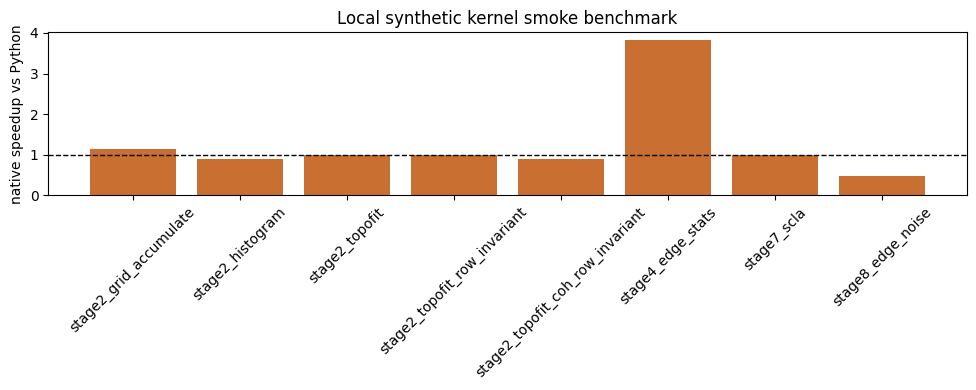

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bench["kernel"], bench["speedup_native_vs_python"], color="#c96f32")
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("native speedup vs Python")
ax.set_title("Local synthetic kernel smoke benchmark")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


## Practical rule

Use Python when debugging numerical behavior, native when running CPU-optimized kernels, CUDA only when the provider is available, `verify` for one run versus one golden dataset, `make audit` for parity claims, and `make benchmark` for speed claims.
